# A Theory Companion for Electoral Dynamics

This notebook is meant to sit next to the paper rather than replace it. The paper develops a geometric way to think about repeated elections: what matters is not only who wins in one round, but how central the realized winning outcome stays as voters and candidates keep updating over time.

The simulations here are designed to track the same objects the paper talks about. In particular, the notebook follows the winner radius, the supporter-centroid radius, the camp displacement asymmetry metric, a weighted combination of winner centrality and supporter alignment, and a coverage measure that asks whether the candidate slate actually spans the political center of the electorate.

This revision tries to answer three concrete objections to the earlier draft of the notebook. First, it now runs a targeted search for cases where the weighted Fractional objective has an interior minimum. Second, it reports the camp asymmetry metric instead of only defining it. Third, it separates candidate-side runs that satisfy the paper's `\mu = 0` restriction from descriptive runs that do not.

It also adds a small oracle comparison: one unconstrained benchmark chooses the most central winner each round, while another chooses the winner that most reduces next-round voter disagreement. That thought experiment helps separate winner centrality from depolarization more sharply than ordinary system comparisons can.

---
## Imports and configuration


In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
if (cwd / "configs").exists() and (cwd / "electoral_sim").exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from electoral_sim.ballots import BallotProfile
from electoral_sim.candidates import CandidateSet

import notebooks.helpers.electoral_dynamics_theory as theory

theory = importlib.reload(theory)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:0.3f}")

BASE_SEED = 7
DIM_NAMES = ["economic", "social"]

SYSTEMS = [
    "Plurality",
    "Score",
    "Condorcet",
    theory.fractional_continuous_name(0.30),
    theory.fractional_continuous_name(1.00),
]
MU0_DYNAMICS = theory.THEORY_MU0_CANDIDATE_MODELS


---
## Preliminary setup

The paper works with repeated elections. At round $t$, voter $i$ sits at position $x_i^{(t)}$, candidate $j$ sits at position $c_j^{(t)}$, and the electoral rule produces an outcome position $w_s^{(t)}$ under system $s$.

The notebook tracks five main geometric quantities.

First, voter disagreement is the empirical variance

$$
D^{(t)} = \frac{1}{n}\sum_{i=1}^n \lVert x_i^{(t)} - \bar{x}^{(t)} \rVert_2^2,
$$

where $\bar{x}^{(t)}$ is the electorate mean.

Second, the paper's winner-centrality object is the winner radius

$$
R_t = \max_i \lVert x_i^{(t)} - w_s^{(t)} \rVert_2.
$$

Third, the candidate-side object is the supporter-centroid radius

$$
S_t = \max_j \lVert c_j^{(t)} - s_j^{(t)} \rVert_2,
$$

where $s_j^{(t)}$ is candidate $j$'s supporter centroid.

Fourth, for camp-balance comparisons the notebook reports the normalized displacement asymmetry

$$
A^t = \frac{\lVert \mu_{\min}^t - \mu_{\min}^0 \rVert_2 - \lVert \mu_{\maj}^t - \mu_{\maj}^0 \rVert_2}{\lVert \mu_{\min}^t - \mu_{\min}^0 \rVert_2 + \lVert \mu_{\maj}^t - \mu_{\maj}^0 \rVert_2 + \varepsilon}.
$$

Values near zero mean the two camps move by similar amounts. Positive values mean the smaller camp is doing more of the moving.

Fifth, to combine winner centrality and supporter alignment, the notebook uses

$$
L_\alpha(t) = \alpha R_t + (1-\alpha) S_t.
$$

Finally, the notebook also computes a coverage gap: the distance from the electorate's minimax center to the convex hull of the candidate slate.

One analysis choice matters for $S_t$. The simulator has true fractional voter-to-candidate weights for the continuous Fractional rule, but single-winner systems do not come with one canonical supporter-weight matrix. So this notebook uses a simple rule-facing convention:

- `Plurality` uses hard first-choice assignment,
- `Score` uses normalized score weights,
- `Condorcet` uses normalized rank-point weights,
- `Fractional Continuous` uses its actual Boltzmann weight matrix.

That means the supporter geometry should be read as an analysis-side proxy designed to mirror the paper's hard-versus-soft supporter maps.


---
## Helper overview


In [2]:
theory.theory_helper_overview()

,component,options,purpose
0,Winner primitive,"winner_radius, mean_winner_distance",Directly evaluate the voter-side centrality ob...
1,Supporter primitive,"supporter_centroids, supporter_centroid_radius",Measure the candidate-side geometry S_t using ...
2,Continuous fractional family,Fractional Continuous (sigma=...),Run the convex-combination fractional family u...
3,Asymmetry and theory-backed candidate runs,"normalized_displacement_asymmetry, Base reinfo...",Track camp-level movement asymmetry and isolat...
4,Coverage geometry,"minimax_center, coverage_gap",Numerically study the slate-coverage bound for...
5,Oracle objective comparison,"Centrality oracle, Depolarization oracle",Contrast one-step winner-centrality optimizati...


---
## Notebook-local display helpers

The heavier simulation logic lives in `notebooks/helpers/electoral_dynamics_theory.py`. The next cell only defines a few plotting and formatting helpers so the rest of the notebook can stay focused on the paper-facing ideas.


In [3]:

def trace_system_states(
    electorate,
    candidates,
    system_name,
    n_steps=10,
    voter_dynamics="Backlash",
    candidate_dynamics="Broad coalition chase",
    electorate_name=None,
    seed=0,
):
    """Roll one system forward and keep the start/end states for plotting."""
    system = theory.build_theory_system(system_name)
    voter_spec = theory.build_voter_dynamics(voter_dynamics)
    candidate_spec = theory.build_theory_candidate_dynamics(candidate_dynamics)

    current_electorate = theory._copy_electorate(electorate)
    current_candidates = theory._copy_candidates(candidates)
    start_electorate = theory._copy_electorate(electorate)
    start_candidates = theory._copy_candidates(candidates)
    final_outcome = None

    for step in range(n_steps):
        ballots = BallotProfile.from_preferences(current_electorate, current_candidates)
        result = system.run(ballots, current_candidates)
        final_outcome = result.outcome_position
        current_electorate = theory.advance_voters(
            current_electorate,
            winner_position=result.outcome_position,
            dynamics=voter_spec,
            seed=seed + 100 + step,
        )
        current_candidates = theory.advance_candidates(
            current_electorate,
            current_candidates,
            dynamics=candidate_spec,
        )

    return {
        "start_electorate": start_electorate,
        "start_candidates": start_candidates,
        "end_electorate": current_electorate,
        "end_candidates": current_candidates,
        "final_outcome": final_outcome,
    }


def plot_spatial_snapshot(ax, electorate, candidates, title, outcome_position=None):
    if electorate.group_ids is None:
        ax.scatter(
            electorate.preferences[:, 0],
            electorate.preferences[:, 1],
            s=8,
            alpha=0.10,
            color="#4C78A8",
            edgecolor="none",
        )
    else:
        palette = sns.color_palette("Set2", n_colors=len(np.unique(electorate.group_ids)))
        for color, group_id in zip(palette, np.unique(electorate.group_ids)):
            mask = electorate.group_ids == group_id
            ax.scatter(
                electorate.preferences[mask, 0],
                electorate.preferences[mask, 1],
                s=8,
                alpha=0.10,
                color=color,
                edgecolor="none",
            )

    ax.scatter(
        candidates.positions[:, 0],
        candidates.positions[:, 1],
        s=90,
        color="#D62728",
        marker="X",
        linewidth=0.6,
        edgecolor="white",
    )

    if outcome_position is not None:
        ax.scatter(
            outcome_position[0],
            outcome_position[1],
            s=140,
            color="#111111",
            marker="*",
            edgecolor="white",
            linewidth=0.7,
        )

    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(DIM_NAMES[0])
    ax.set_ylabel(DIM_NAMES[1])


def plot_start_end_gallery(state_map, system_order):
    fig, axes = plt.subplots(len(system_order), 2, figsize=(10, 3.1 * len(system_order)), dpi=150)
    if len(system_order) == 1:
        axes = np.array([axes])

    for row_idx, system_name in enumerate(system_order):
        state = state_map[system_name]
        plot_spatial_snapshot(
            axes[row_idx, 0],
            state["start_electorate"],
            state["start_candidates"],
            title=f"{system_name}: start",
        )
        plot_spatial_snapshot(
            axes[row_idx, 1],
            state["end_electorate"],
            state["end_candidates"],
            title=f"{system_name}: end",
            outcome_position=state["final_outcome"],
        )

    fig.tight_layout()
    return fig


def plot_theory_trajectories(trajectory_df, metrics, system_order=None):
    system_order = system_order or list(trajectory_df["system"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), dpi=150)
    axes = axes.ravel()
    palette = dict(zip(system_order, sns.color_palette("tab10", n_colors=len(system_order))))

    for ax, metric in zip(axes, metrics):
        for system_name in system_order:
            system_df = trajectory_df[trajectory_df["system"] == system_name].sort_values("step")
            ax.plot(
                system_df["step"],
                system_df[metric],
                marker="o",
                linewidth=2,
                markersize=4,
                color=palette[system_name],
                label=system_name,
            )
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("round")
        ax.grid(alpha=0.25)
    axes[0].legend(frameon=False, loc="best")
    fig.tight_layout()
    return fig


def summarize_system_means(summary_df):
    metrics = [
        "winner_radius_end",
        "supporter_centroid_radius_end",
        "voter_variance_delta",
        "candidate_variance_delta",
    ]
    return (
        summary_df.groupby("system", as_index=False)[metrics]
        .mean()
        .sort_values("winner_radius_end")
        .reset_index(drop=True)
    )


def plot_system_metric_heatmaps(summary_df, system_order, title_prefix=""):
    metric_labels = {
        "winner_radius_end": "winner radius end",
        "supporter_centroid_radius_end": "supporter radius end",
        "voter_variance_delta": "voter variance change",
        "candidate_variance_delta": "candidate variance change",
    }
    system_means = summarize_system_means(summary_df).set_index("system").reindex(system_order)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=150)
    left = system_means[["winner_radius_end", "supporter_centroid_radius_end"]].rename(columns=metric_labels)
    right = system_means[["voter_variance_delta", "candidate_variance_delta"]].rename(columns=metric_labels)

    sns.heatmap(left, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0], cbar=False)
    sns.heatmap(right, annot=True, fmt=".3f", cmap="RdBu_r", center=0.0, ax=axes[1], cbar=False)
    axes[0].set_title(f"{title_prefix}end-state geometry")
    axes[1].set_title(f"{title_prefix}spread changes")
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
    fig.tight_layout()
    return fig


def plot_asymmetry_heatmap(asymmetry_summary, system_order):
    pivot = asymmetry_summary.pivot(index="ratio", columns="system", values="normalized_displacement_asymmetry_end")
    pivot = pivot.reindex(index=theory.RATIO_ORDER, columns=system_order)
    fig, ax = plt.subplots(figsize=(10, 3.8), dpi=150)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0.0, ax=ax)
    ax.set_title("Camp displacement asymmetry by system and camp balance")
    ax.set_xlabel("")
    ax.set_ylabel("")
    fig.tight_layout()
    return fig


def plot_ratio_asymmetry_trajectories(trajectory_map, system_order):
    fig, axes = plt.subplots(1, len(trajectory_map), figsize=(4.6 * len(trajectory_map), 3.7), dpi=150, sharey=True)
    axes = np.atleast_1d(axes)
    palette = dict(zip(system_order, sns.color_palette("tab10", n_colors=len(system_order))))

    for ax, (ratio_name, trajectory_df) in zip(axes, trajectory_map.items()):
        for system_name in system_order:
            system_df = trajectory_df[trajectory_df["system"] == system_name].sort_values("step")
            ax.plot(
                system_df["step"],
                system_df["normalized_displacement_asymmetry"],
                marker="o",
                linewidth=2,
                markersize=4,
                color=palette[system_name],
                label=system_name,
            )
        ax.axhline(0.0, color="#333333", linewidth=1, alpha=0.5)
        ax.set_title(ratio_name)
        ax.set_xlabel("round")
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("normalized displacement asymmetry")
    axes[0].legend(frameon=False, bbox_to_anchor=(1.02, 1.02), loc="upper left")
    fig.tight_layout()
    return fig


def plot_mu_zero_candidate_heatmaps(summary_df, system_order):
    supporter = summary_df.pivot_table(
        index="candidate_dynamics",
        columns="system",
        values="supporter_centroid_radius_end",
        aggfunc="mean",
    ).reindex(index=MU0_DYNAMICS, columns=system_order)
    spread = summary_df.pivot_table(
        index="candidate_dynamics",
        columns="system",
        values="candidate_variance_delta",
        aggfunc="mean",
    ).reindex(index=MU0_DYNAMICS, columns=system_order)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), dpi=150)
    sns.heatmap(supporter, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0], cbar=False)
    sns.heatmap(spread, annot=True, fmt=".3f", cmap="RdBu_r", center=0.0, ax=axes[1], cbar=False, yticklabels=False)
    axes[0].set_title("Theory-backed candidate primitive: $S_t$")
    axes[1].set_title("Candidate polarization change under $\\mu = 0$")
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelrotation=0)
    fig.subplots_adjust(wspace=0.18)
    fig.tight_layout()
    return fig


def plot_sigma_case_curves(search_df, selections):
    fig, axes = plt.subplots(1, len(selections), figsize=(5.0 * len(selections), 3.8), dpi=150, sharey=False)
    axes = np.atleast_1d(axes)
    for ax, (case_name, alpha) in zip(axes, selections):
        alpha_label = f"{alpha:.2f}"
        column = f"weighted_cost_alpha_{alpha_label}"
        case_df = search_df[search_df["case_name"] == case_name].sort_values("sigma")
        ax.plot(case_df["sigma"], case_df[column], marker="o", linewidth=2, color="#4C78A8")
        best_idx = int(case_df[column].to_numpy().argmin())
        ax.scatter(
            case_df.iloc[best_idx]["sigma"],
            case_df.iloc[best_idx][column],
            s=80,
            color="#D62728",
            zorder=3,
        )
        ax.set_title(f"{case_name}\nalpha={alpha:.2f}")
        ax.set_xlabel("sigma")
        ax.set_ylabel("weighted cost")
        ax.grid(alpha=0.25)
    fig.tight_layout()
    return fig


---
## A representative repeated-election path

The first exercise keeps the setting fixed and watches the paper's core quantities over time. The electorate is `Bridge conflict`, the candidate slate is `Centrist ladder`, voters follow the `Backlash` mechanism, and candidates follow `Broad coalition chase`.

This section is useful for intuition, but it should be read with one caveat in mind. Because `Broad coalition chase` has positive centroid pull, the candidate-side `S_t` comparisons here are descriptive. The voter-side `R_t` story is still directly aligned with the theory, but the candidate-side proposition is treated more carefully later in the notebook.


In [4]:
example_electorate = theory.build_polarization_electorate(
    "Bridge conflict",
    seed=BASE_SEED,
    n_voters=1000,
    ratio_name="Original",
)
example_candidates = theory.build_polarization_candidates("Centrist ladder")

trajectory_df = theory.run_theory_trajectory(
    example_electorate,
    example_candidates,
    system_names=SYSTEMS,
    n_steps=10,
    voter_dynamics="Backlash",
    candidate_dynamics="Broad coalition chase",
    electorate_name="Bridge conflict",
    seed=BASE_SEED,
)
trajectory_summary = theory.summarize_theory_trajectory_changes(trajectory_df)

trajectory_summary[[
    "system",
    "winner_radius_end",
    "supporter_centroid_radius_end",
    "voter_variance_delta",
    "candidate_variance_delta",
    "normalized_displacement_asymmetry_end",
]]


,system,winner_radius_end,supporter_centroid_radius_end,voter_variance_delta,candidate_variance_delta,normalized_displacement_asymmetry_end
0,Plurality,0.894,0.069,-0.002,-0.014,0.026
1,Score,0.540,0.272,-0.038,-0.020,0.080
2,Condorcet,0.533,0.088,-0.038,-0.020,-0.002
3,Fractional Continuous (sigma=0.30),0.516,0.186,-0.038,-0.020,-0.003
4,Fractional Continuous (sigma=1.00),0.517,0.270,-0.038,-0.020,-0.003


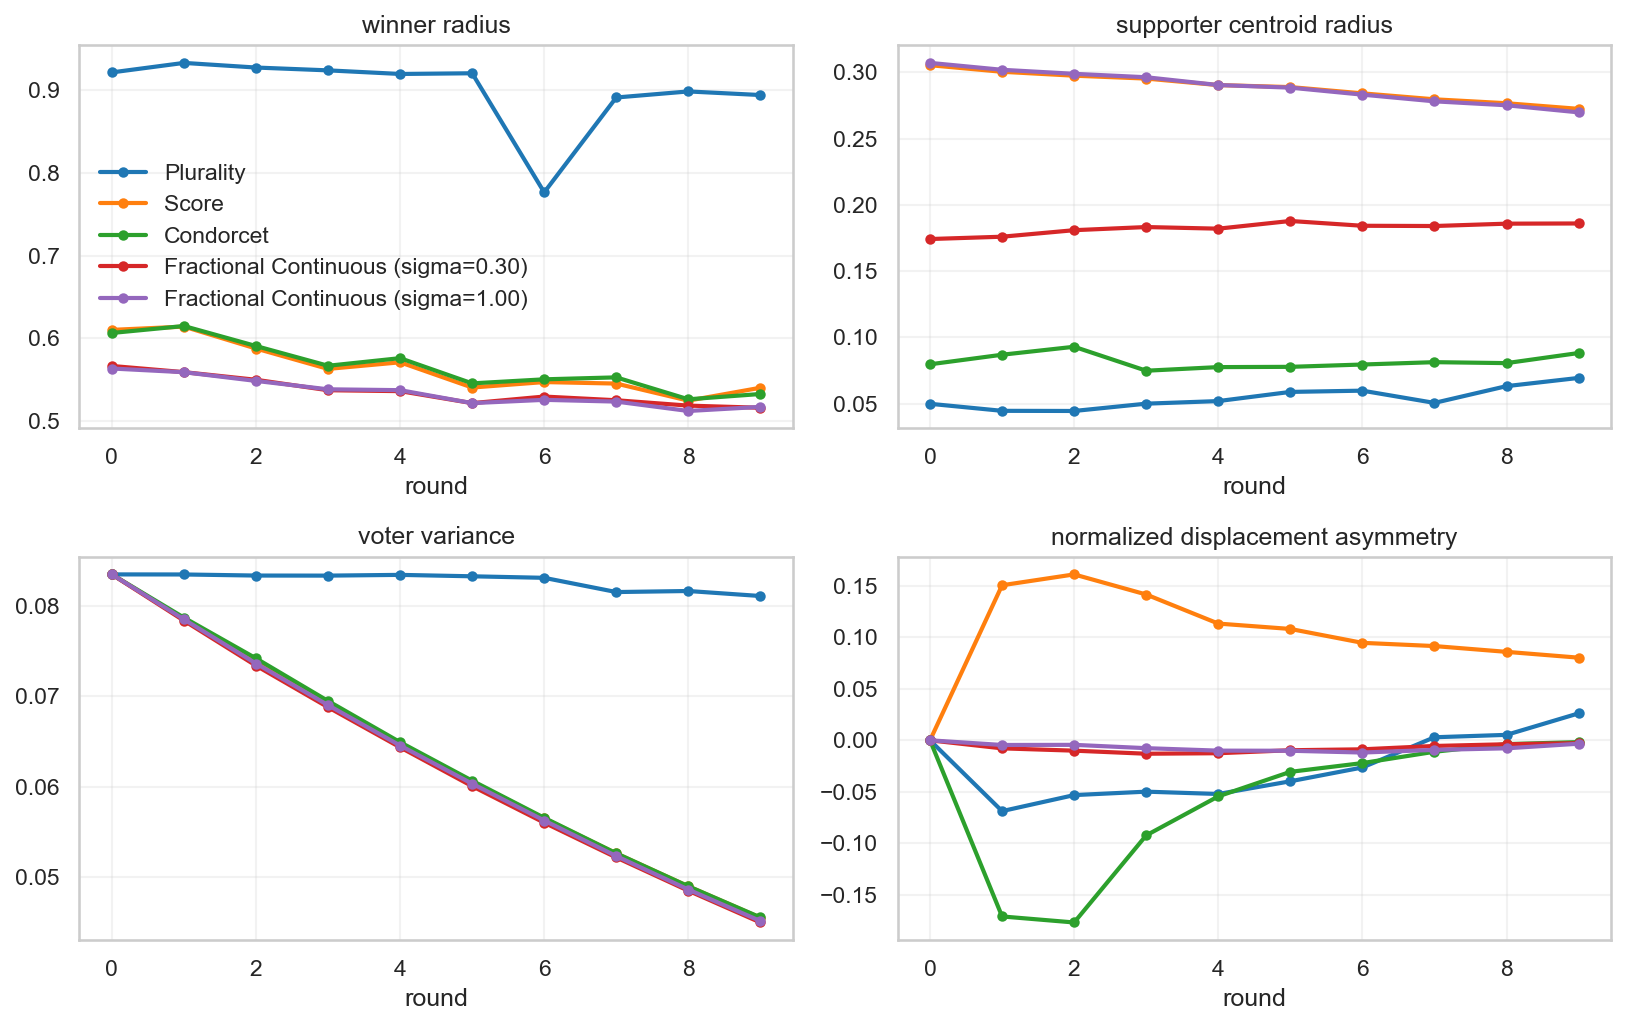

In [5]:
plot_theory_trajectories(
    trajectory_df,
    metrics=[
        "winner_radius",
        "supporter_centroid_radius",
        "voter_variance",
        "normalized_displacement_asymmetry",
    ],
    system_order=SYSTEMS,
);


The next figure makes the same comparison spatially. Each row starts from the same electorate and candidate field. Only the electoral rule changes.


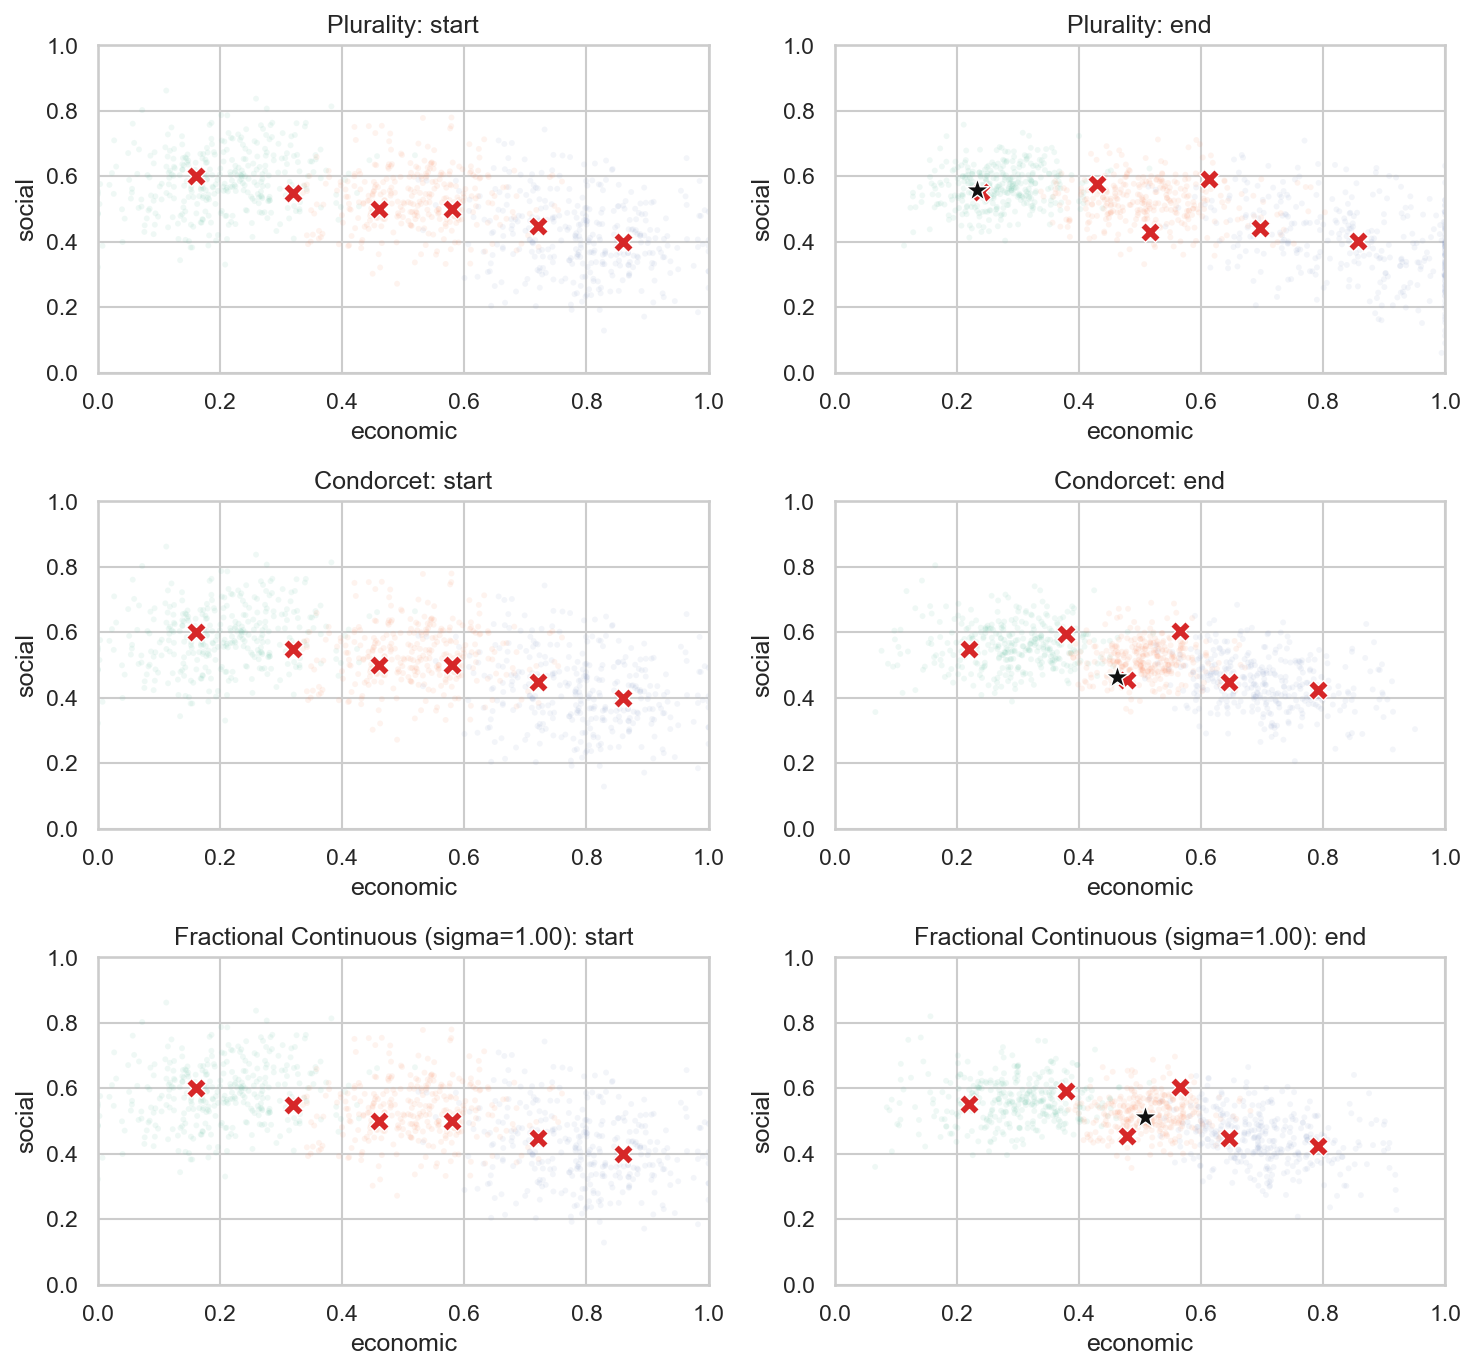

In [6]:
state_gallery = {
    system_name: trace_system_states(
        example_electorate,
        example_candidates,
        system_name,
        n_steps=10,
        voter_dynamics="Backlash",
        candidate_dynamics="Broad coalition chase",
        electorate_name="Bridge conflict",
        seed=BASE_SEED + 19 * idx,
    )
    for idx, system_name in enumerate(["Plurality", "Condorcet", theory.fractional_continuous_name(1.00)])
}

plot_start_end_gallery(
    state_gallery,
    ["Plurality", "Condorcet", theory.fractional_continuous_name(1.00)],
);


Even in this descriptive setting, the main pattern is already visible. `Plurality` keeps the realized winner much farther from parts of the electorate than the other rules, while `Condorcet` and the continuous Fractional variants bring the outcome closer to the electorate center. That is the voter-side mechanism the paper is built around.


---
## Voter-side grid summary and the descriptive `\mu > 0` comparison

A single trajectory can always be lucky or unlucky. So the next block runs a broader grid over electorate families, camp-balance settings, candidate slates, and voter dynamics while holding candidate dynamics at `Broad coalition chase`.

This section still mixes in descriptive candidate-side information because `Broad coalition chase` uses positive centroid pull. It is mainly here to summarize the voter-side primitive and to keep continuity with the paper's broader simulation story.


In [7]:
broad_grid = theory.run_theory_grid(
    electorate_names=theory.ELECTORATE_ORDER,
    ratio_names=theory.RATIO_ORDER,
    candidate_names=["Centrist ladder", "Polarized elites"],
    voter_dynamics_names=theory.VOTER_MODEL_ORDER,
    candidate_dynamics_names=["Broad coalition chase"],
    system_names=SYSTEMS,
    n_steps=8,
    n_voters=500,
    seed=BASE_SEED + 4,
)

summarize_system_means(broad_grid)


,system,winner_radius_end,supporter_centroid_radius_end,voter_variance_delta,candidate_variance_delta
0,Fractional Continuous (sigma=1.00),0.465,0.290,-0.036,-0.039
1,Fractional Continuous (sigma=0.30),0.472,0.196,-0.036,-0.039
2,Score,0.528,0.287,-0.034,-0.039
3,Condorcet,0.529,0.111,-0.033,-0.039
4,Plurality,0.679,0.073,-0.019,-0.038


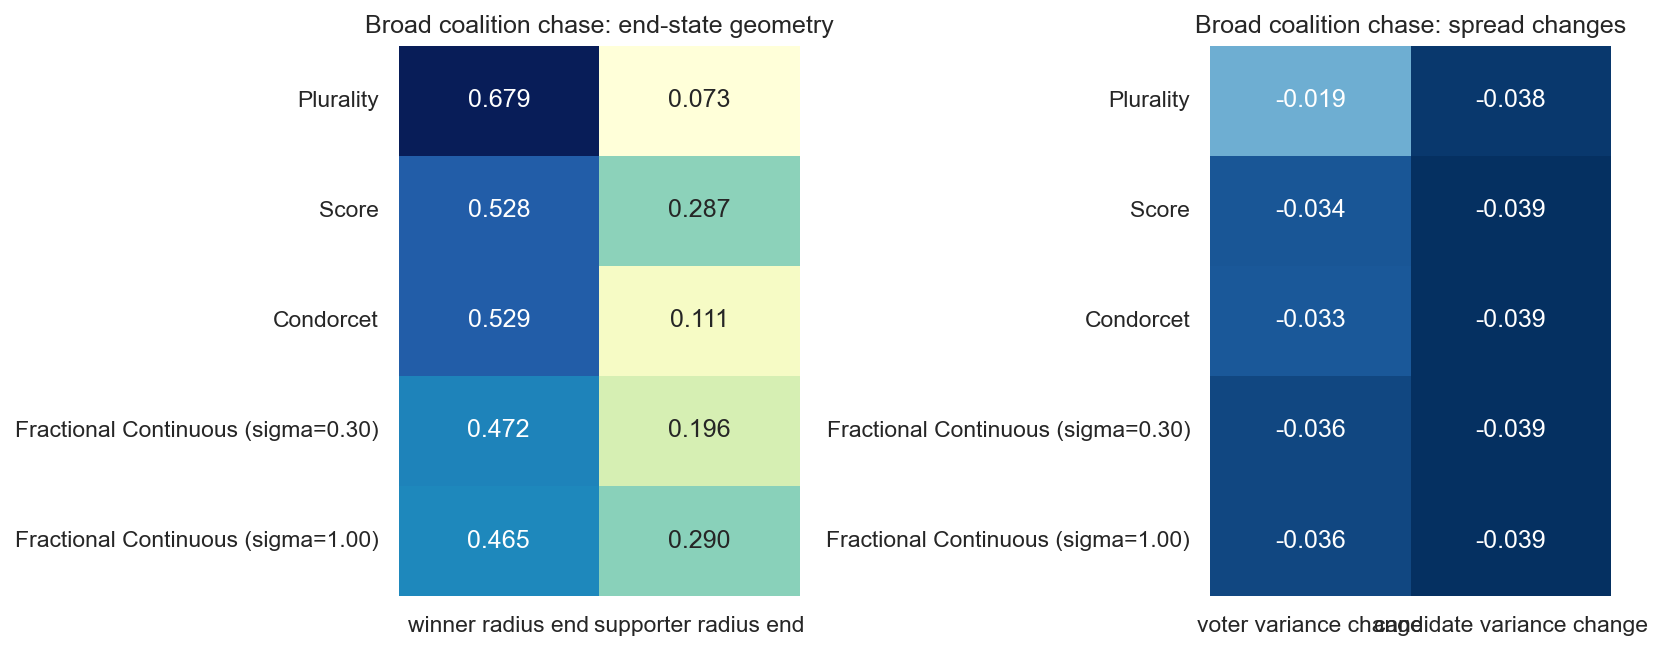

In [8]:
plot_system_metric_heatmaps(broad_grid, SYSTEMS, title_prefix="Broad coalition chase: ");

In these broader runs, the voter-side ranking remains clear. The continuous Fractional variants usually produce the smallest end-state winner radii, `Condorcet` and `Score` sit in the middle, and `Plurality` is worst on winner centrality by a wide margin. That is exactly the dimension on which the paper's comparison theorem speaks.

The candidate-side numbers in this table are still informative, but they should not be read as direct evidence for the candidate-side proposition because `\mu > 0` here.


---
## Camp displacement asymmetry

The paper defines the camp displacement asymmetry metric $A^t$, so this notebook should actually report it.

The first view below aggregates end-of-run asymmetry by electoral system and camp-balance setting. The second view keeps one electorate family fixed and shows how $A^t$ evolves over time for the three camp-balance settings.


In [9]:
asymmetry_summary = theory.summarize_asymmetry_by_system(broad_grid)
asymmetry_summary


,ratio,system,normalized_displacement_asymmetry_end,case_count
0,50:50,Condorcet,0.025,18
1,50:50,Fractional Continuous (sigma=0.30),-0.055,18
2,50:50,Fractional Continuous (sigma=1.00),-0.040,18
3,50:50,Plurality,0.099,18
4,50:50,Score,0.001,18
5,70:30,Condorcet,0.242,18
6,70:30,Fractional Continuous (sigma=0.30),0.170,18
7,70:30,Fractional Continuous (sigma=1.00),0.350,18
8,70:30,Plurality,0.349,18
9,70:30,Score,0.268,18


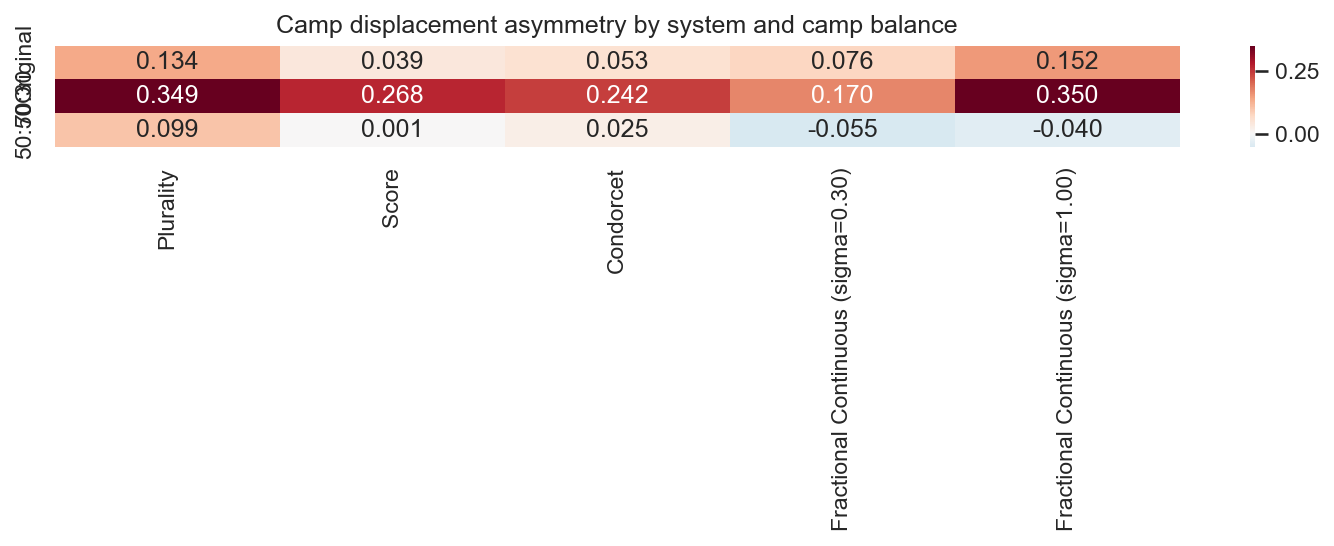

In [10]:
plot_asymmetry_heatmap(asymmetry_summary, SYSTEMS);

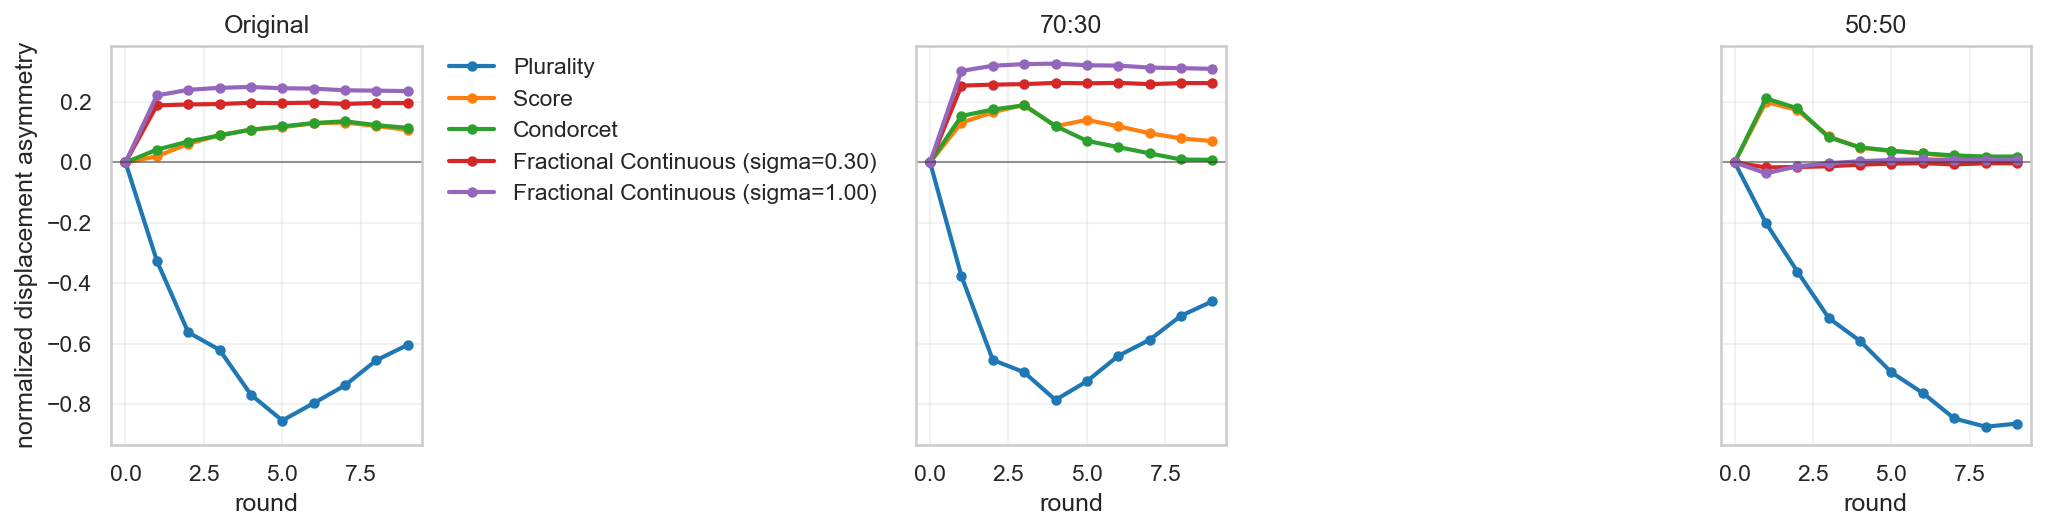

In [11]:
asymmetry_trajectory_map = {}
for ratio_name in theory.RATIO_ORDER:
    electorate = theory.build_polarization_electorate(
        "Asymmetric resentment",
        seed=BASE_SEED + 10,
        n_voters=900,
        ratio_name=ratio_name,
    )
    candidates = theory.build_polarization_candidates("Polarized elites")
    asymmetry_trajectory_map[ratio_name] = theory.run_theory_trajectory(
        electorate,
        candidates,
        system_names=SYSTEMS,
        n_steps=10,
        voter_dynamics="Backlash",
        candidate_dynamics="Broad coalition chase",
        electorate_name="Asymmetric resentment",
        seed=BASE_SEED + 20,
    )

plot_ratio_asymmetry_trajectories(asymmetry_trajectory_map, SYSTEMS);


Two things stand out. First, asymmetry is modest in `50:50` designs and much more visible in `70:30` designs, which is exactly when the metric is supposed to matter. Second, `Plurality` and the softer continuous Fractional rule often produce more positive asymmetry than `Condorcet` or `Score` in the `70:30` setting. So the camp-balance discussion is now tied to a concrete reported object rather than only to verbal interpretation.


---
## Theory-backed candidate-side runs with `\mu = 0`

Proposition 3.10 on the candidate side requires `\mu = 0`, so this section isolates candidate dynamics that satisfy that restriction.

The first mechanism is `Static candidates`, which is a useful baseline because it removes candidate motion entirely. The second is `Base reinforcement (mu=0)`, a restricted version of base reinforcement that keeps supporter chase and rival differentiation but turns off centroid pull.


In [12]:
mu0_grid = theory.run_theory_grid(
    electorate_names=theory.ELECTORATE_ORDER,
    ratio_names=theory.RATIO_ORDER,
    candidate_names=["Centrist ladder", "Polarized elites"],
    voter_dynamics_names=theory.VOTER_MODEL_ORDER,
    candidate_dynamics_names=MU0_DYNAMICS,
    system_names=SYSTEMS,
    n_steps=8,
    n_voters=500,
    seed=BASE_SEED + 12,
)

mu0_grid.groupby(["candidate_dynamics", "system"], as_index=False)[[
    "supporter_centroid_radius_end",
    "candidate_variance_delta",
]].mean()


,candidate_dynamics,system,supporter_centroid_radius_end,candidate_variance_delta
0,Base reinforcement (mu=0),Condorcet,0.321,0.052
1,Base reinforcement (mu=0),Fractional Continuous (sigma=0.30),0.414,0.051
2,Base reinforcement (mu=0),Fractional Continuous (sigma=1.00),0.513,0.051
3,Base reinforcement (mu=0),Plurality,0.156,0.053
4,Base reinforcement (mu=0),Score,0.495,0.050
5,Static candidates,Condorcet,0.224,0.000
6,Static candidates,Fractional Continuous (sigma=0.30),0.315,0.000
7,Static candidates,Fractional Continuous (sigma=1.00),0.409,0.000
8,Static candidates,Plurality,0.083,0.000
9,Static candidates,Score,0.409,0.000


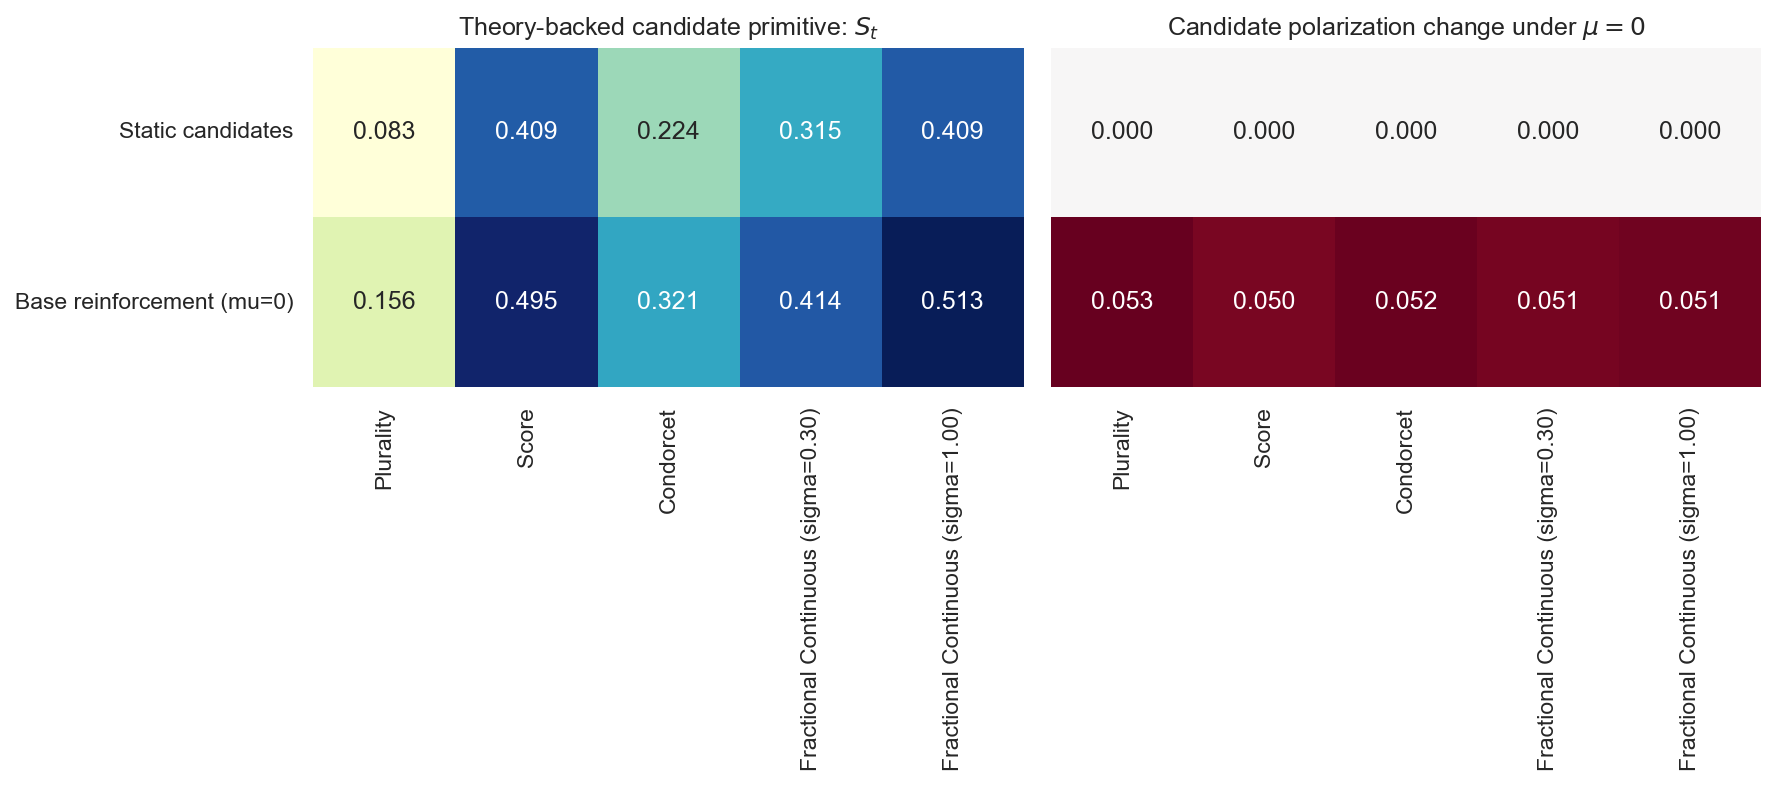

In [13]:
plot_mu_zero_candidate_heatmaps(mu0_grid, SYSTEMS);

This is the candidate-side section that lines up most directly with the theory. The system ordering is not identical to the voter-side one, which is the point. `Plurality` tends to look strong on supporter-centroid radius because hard assignment keeps candidates closely tied to their nearest supporters, while the smoother Fractional variants often look worse on that particular object. That is the structural tradeoff the paper emphasizes: winner centrality and candidate base alignment are different goals.


---
## A small coverage illustration

The paper also argues that candidate coverage matters. If the candidate convex hull misses the part of the map where a central winner would need to sit, then even a smooth rule has less room to produce a very central outcome.

The built-in slates in the repo already cover the electorate center fairly well, so the raw coverage gaps there are often small. To make the mechanism easier to see, the next example uses three hand-built slates on the same electorate.


In [14]:
coverage_electorate = theory.build_polarization_electorate(
    "Bridge conflict",
    seed=BASE_SEED + 2,
    n_voters=1000,
)

coverage_slates = {
    "Centered bridge slate": CandidateSet(
        positions=np.array([
            [0.18, 0.60],
            [0.34, 0.55],
            [0.48, 0.51],
            [0.62, 0.49],
            [0.78, 0.42],
        ]),
        labels=["A", "B", "C", "D", "E"],
    ),
    "Extreme-only slate": CandidateSet(
        positions=np.array([
            [0.10, 0.72],
            [0.18, 0.62],
            [0.82, 0.38],
            [0.90, 0.28],
        ]),
        labels=["A", "B", "C", "D"],
    ),
    "One-sided slate": CandidateSet(
        positions=np.array([
            [0.12, 0.66],
            [0.22, 0.58],
            [0.34, 0.54],
            [0.44, 0.50],
            [0.58, 0.46],
        ]),
        labels=["A", "B", "C", "D", "E"],
    ),
}

coverage_rows = []
for slate_name, candidates in coverage_slates.items():
    gap = theory.compute_coverage_gap(coverage_electorate, candidates)
    trajectory = theory.run_theory_trajectory(
        coverage_electorate,
        candidates,
        system_names=SYSTEMS,
        n_steps=8,
        voter_dynamics="Backlash",
        candidate_dynamics="Static candidates",
        electorate_name="Bridge conflict",
        seed=BASE_SEED + 40,
    )
    summary = theory.summarize_theory_trajectory_changes(trajectory)
    summary["slate"] = slate_name
    summary["coverage_gap"] = gap
    coverage_rows.append(summary)
coverage_df = pd.concat(coverage_rows, ignore_index=True)
coverage_df[["slate", "coverage_gap", "system", "winner_radius_end"]]


,slate,coverage_gap,system,winner_radius_end
0,Centered bridge slate,0.027,Plurality,0.839
1,Centered bridge slate,0.027,Score,0.620
2,Centered bridge slate,0.027,Condorcet,0.598
3,Centered bridge slate,0.027,Fractional Continuous (sigma=0.30),0.603
4,Centered bridge slate,0.027,Fractional Continuous (sigma=1.00),0.592
5,Extreme-only slate,0.000,Plurality,0.985
6,Extreme-only slate,0.000,Score,0.846
7,Extreme-only slate,0.000,Condorcet,0.998
8,Extreme-only slate,0.000,Fractional Continuous (sigma=0.30),0.579
9,Extreme-only slate,0.000,Fractional Continuous (sigma=1.00),0.556


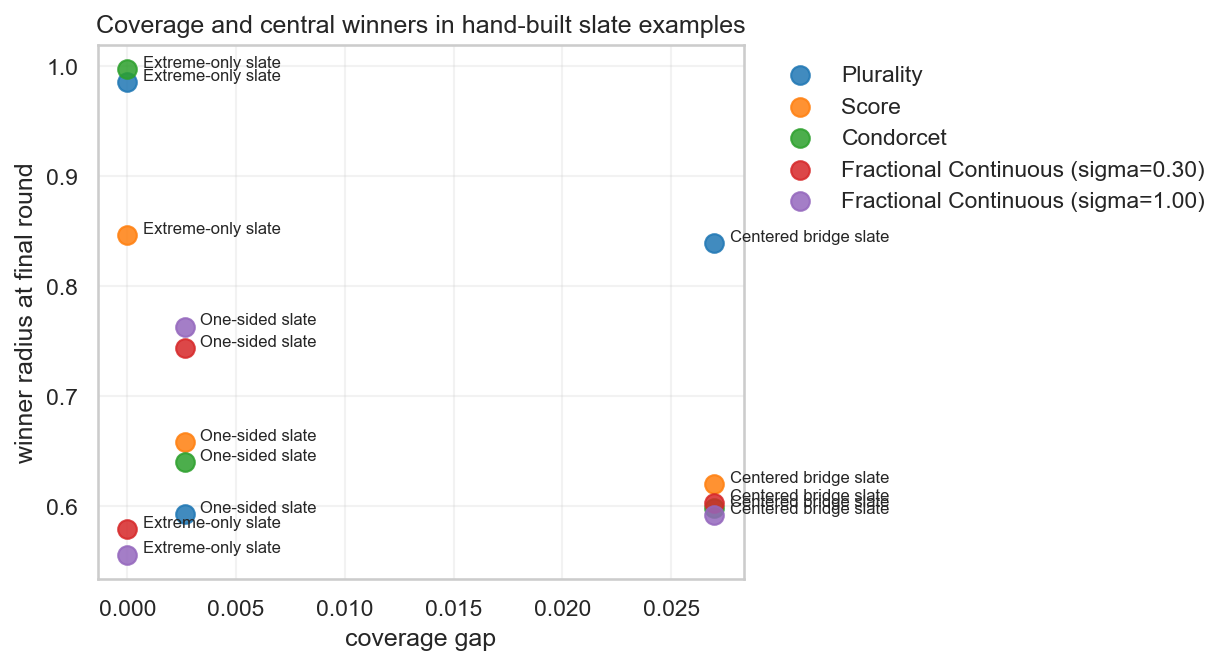

In [15]:
fig, ax = plt.subplots(figsize=(8.4, 4.6), dpi=150)
palette = dict(zip(SYSTEMS, sns.color_palette("tab10", n_colors=len(SYSTEMS))))
for system_name in SYSTEMS:
    system_df = coverage_df[coverage_df["system"] == system_name]
    ax.scatter(
        system_df["coverage_gap"],
        system_df["winner_radius_end"],
        s=80,
        alpha=0.85,
        color=palette[system_name],
        label=system_name,
    )
    for _, row in system_df.iterrows():
        ax.text(row["coverage_gap"] + 0.0007, row["winner_radius_end"] + 0.002, row["slate"], fontsize=8)
ax.set_xlabel("coverage gap")
ax.set_ylabel("winner radius at final round")
ax.set_title("Coverage and central winners in hand-built slate examples")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()


The coverage section still plays the same role as before, but now it also helps motivate the targeted sigma search. If the center is poorly covered, the tradeoff between winner centrality and supporter alignment becomes easier to see.


---
## A targeted search for interior minima of the weighted Fractional objective

The earlier version of the notebook showed monotone sigma curves, which left Proposition 5.3 unsupported by example. So this section changes the design on purpose.

The search now does three things differently:

- it extends the sigma range below `0.15` and above `1.50`,
- it tries hand-built and asymmetric cases where the electorate center is harder to cover cleanly,
- it looks at `\alpha` values closer to `0` and `1`, where the tradeoff is more asymmetric.

The goal is not to claim that interior minima are common. The goal is to see whether they appear at all in plausible simulated geometries.


In [16]:
search_df, minima_df = theory.search_fractional_interior_optima(
    sigma_values=[0.03, 0.05, 0.08, 0.12, 0.20, 0.35, 0.60, 1.00, 1.80, 3.00],
    alphas=(0.02, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.98),
    n_steps=8,
    n_voters=500,
    seed=BASE_SEED,
)

interior_minima = minima_df[minima_df["is_interior_minimum"]].copy()
interior_minima


,case_name,alpha,best_sigma,best_cost,is_interior_minimum,left_step_change,right_step_change
5,Asymmetric resentment with polarized elites,0.750,0.050,0.547,True,-0.003,0.018
6,Asymmetric resentment with polarized elites,0.900,1.800,0.625,True,-0.020,0.022
7,Asymmetric resentment with polarized elites,0.950,1.800,0.633,True,-0.023,0.022
8,Asymmetric resentment with polarized elites,0.980,1.800,0.637,True,-0.025,0.022
16,Bridge conflict with extreme-only slate,0.950,0.120,0.443,True,-0.017,0.007
17,Bridge conflict with extreme-only slate,0.980,0.120,0.447,True,-0.018,0.007
27,Two blocs with one-sided manual slate,0.020,0.080,0.198,True,-0.011,0.025
28,Two blocs with one-sided manual slate,0.050,0.080,0.212,True,-0.010,0.026
29,Two blocs with one-sided manual slate,0.100,0.080,0.237,True,-0.009,0.026
30,Two blocs with one-sided manual slate,0.250,0.080,0.311,True,-0.005,0.029


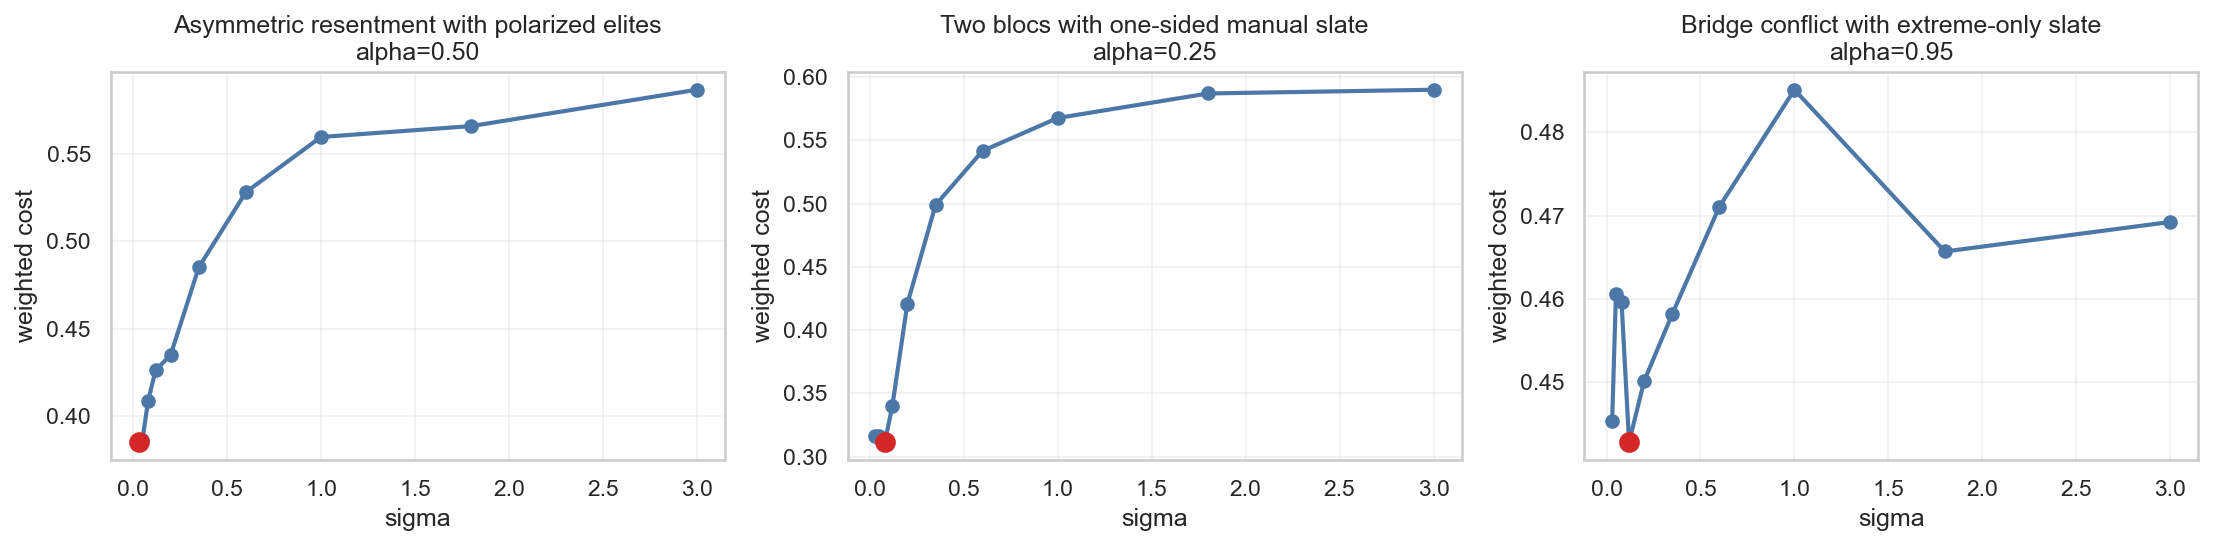

In [17]:
plot_sigma_case_curves(
    search_df,
    selections=[
        ("Asymmetric resentment with polarized elites", 0.50),
        ("Two blocs with one-sided manual slate", 0.25),
        ("Bridge conflict with extreme-only slate", 0.95),
    ],
);


This is the strongest change in the notebook. The targeted search does find interior minima, but not everywhere. They tend to appear in the more stressed designs and often at quite small sigma values. That makes Proposition 5.3 non-vacuous in the simulations without pretending that interior optima are the default outcome in ordinary cases.


---
## Two oracle objectives

This section fixes one benchmark design so the oracle comparison is easy to read.

- `Bridge conflict` is a three-cluster electorate: a left bloc, a bridge cluster near the middle, and a right bloc.
- `70:30` means that, after keeping the bridge voters fixed, one camp holds about 70% of the electorate and the other about 30%.
- `Polarized elites` is a six-candidate slate that leaves relatively weak coverage around the middle.
- `Sorting pressure` is the voter update used in the oracle experiment. For a hypothetical winner position $w$, voter $i$ updates according to

$$
x_i^{(t+1)} = \,\operatorname{clip}\left(x_i^{(t)} + 0.02\bigl(\bar x^{(t)} - x_i^{(t)}\bigr) + 0.01\bigl(w - x_i^{(t)}\bigr) - 0.11\, b_i^{(t)}(w)\bigl(w - x_i^{(t)}\bigr)\right),
$$

where

$$
b_i^{(t)}(w) = \,\operatorname{clip}\!\left(\frac{\lVert w - x_i^{(t)} \rVert_2 - 0.12}{1 - 0.12}, 0, 1\right).
$$

So there is a small pull toward the electorate mean, a small pull toward the winner, and a stronger backlash term when the winner is far away.
- `Base reinforcement (mu=0)` is the candidate update. Candidate $j$ moves by

$$
c_j^{(t+1)} = \,\operatorname{clip}\left(c_j^{(t)} + 0.18\bigl(s_j^{(t)} - c_j^{(t)}\bigr) + 0.06\, r_j^{(t)}\right),
$$

where $s_j^{(t)}$ is candidate $j$'s supporter centroid and $r_j^{(t)}$ points away from the nearest rival. The notation `mu=0` means there is no direct pull toward the electorate mean in this benchmark.

Within that fixed design, the two oracles solve different optimization problems over the full policy square $[0,1]^2$.

The centrality oracle chooses

$$
w_{\mathrm{cent}}^{(t)} \in \arg\min_{w \in [0,1]^2} R_t(w),
\qquad
R_t(w) = \max_i \lVert x_i^{(t)} - w \rVert_2.
$$

The depolarization oracle chooses

$$
w_{\mathrm{dep}}^{(t)} \in \arg\min_{w \in [0,1]^2} D^{(t+1)}(w),
$$

where $D^{(t+1)}(w)$ is the next-round voter disagreement implied by the deterministic voter update above.

The plots below focus only on the quantities that best show how those objectives diverge.

- `winner radius` $R_t$: how far the farthest voter is from the realized outcome.
- `voter disagreement` $D^{(t)}$: the electorate variance defined earlier in the notebook.
- `normalized displacement asymmetry` $A^t$: how much more the smaller camp moves than the larger camp.

A final start/end spatial plot is included because it makes the different trajectories easy to see. Metrics like the candidate-electorate center gap are still available in the helper code, but they are omitted here because they do not separate the two oracles nearly as clearly in this benchmark.



In [18]:
oracle_replicates = theory.run_theory_oracle_replicates(
    electorate_name="Bridge conflict",
    candidate_name="Polarized elites",
    ratio_name="70:30",
    oracle_names=theory.THEORY_ORACLE_ORDER,
    n_steps=16,
    voter_dynamics="Sorting pressure",
    candidate_dynamics="Base reinforcement (mu=0)",
    n_runs=24,
    n_voters=1400,
    seed=BASE_SEED + 1001,
)

oracle_summary = (
    oracle_replicates[oracle_replicates["step"] == oracle_replicates["step"].max()]
    .groupby("system", as_index=False)
    .agg(
        mean_winner_radius_end=("winner_radius", "mean"),
        sd_winner_radius_end=("winner_radius", "std"),
        mean_voter_variance_end=("voter_variance", "mean"),
        sd_voter_variance_end=("voter_variance", "std"),
        mean_normalized_displacement_asymmetry_end=("normalized_displacement_asymmetry", "mean"),
        sd_normalized_displacement_asymmetry_end=("normalized_displacement_asymmetry", "std"),
    )
)
oracle_summary.sort_values("system")



,system,mean_winner_radius_end,sd_winner_radius_end,mean_voter_variance_end,sd_voter_variance_end,mean_normalized_displacement_asymmetry_end,sd_normalized_displacement_asymmetry_end
0,Centrality oracle,0.706,0.021,0.075,0.003,0.156,0.241
1,Depolarization oracle,0.740,0.013,0.073,0.003,-0.320,0.158


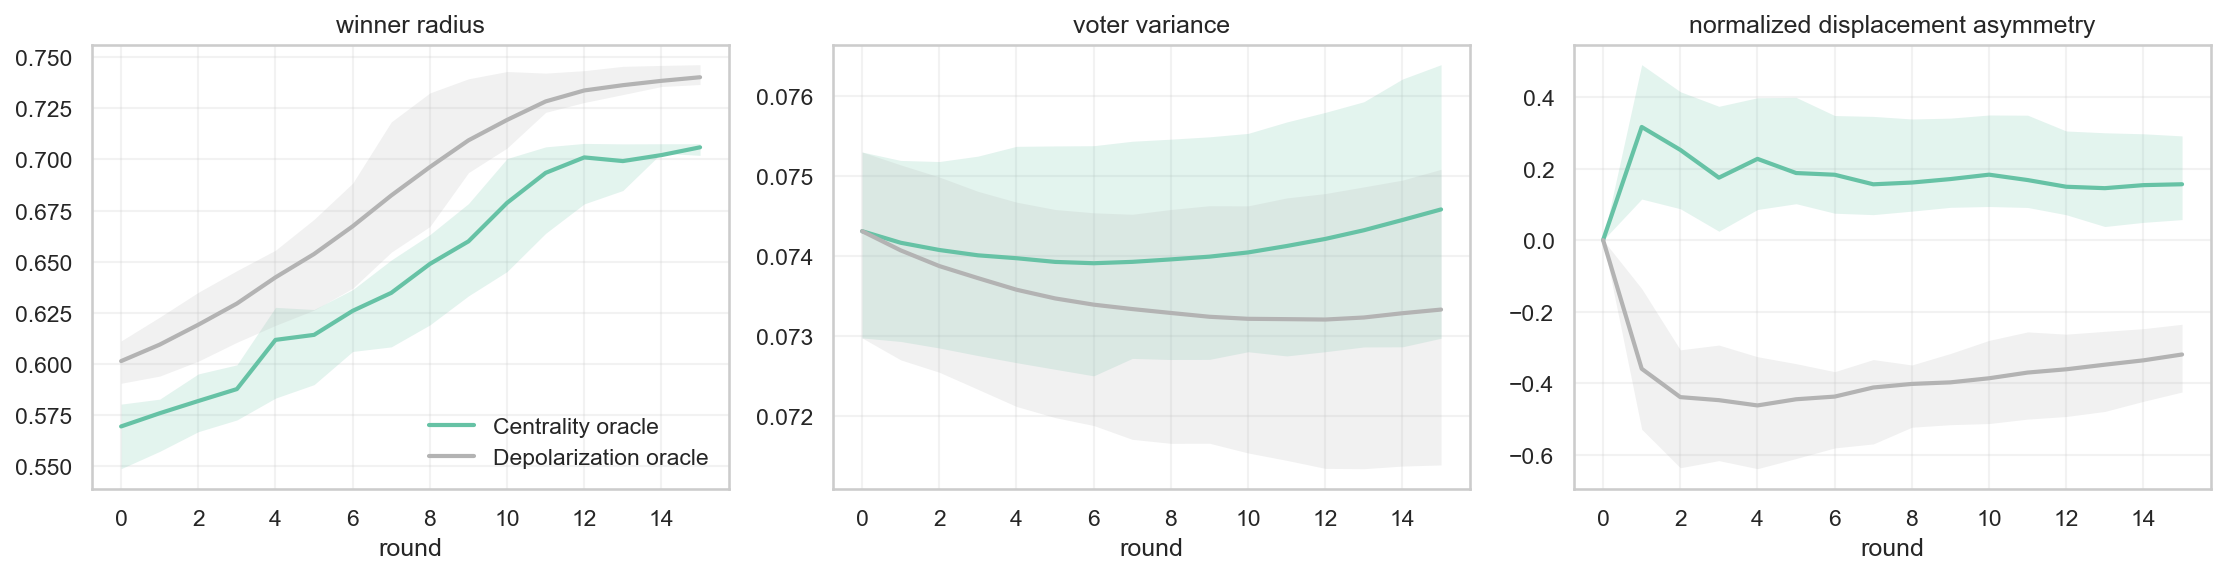

In [19]:
theory.plot_theory_uncertainty_trajectories(
    oracle_replicates,
    metrics=[
        "winner_radius",
        "voter_variance",
        "normalized_displacement_asymmetry",
    ],
    system_order=theory.THEORY_ORACLE_ORDER,
    n_cols=3,
    figsize=(15, 4),
);


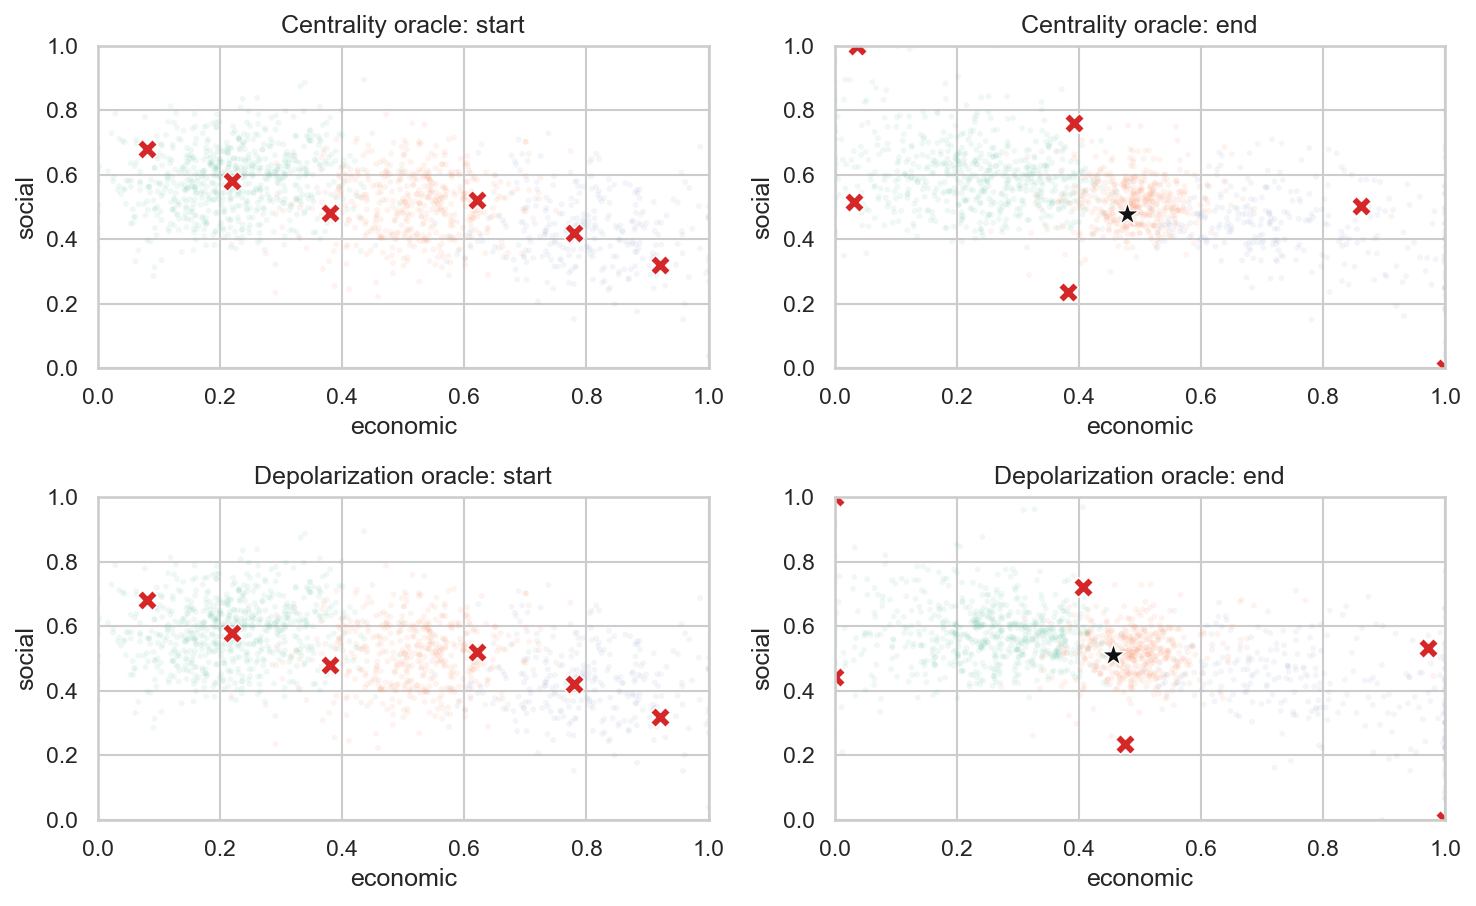

In [20]:
oracle_state_map = {
    oracle_name: theory.trace_theory_oracle_state(
        theory.build_polarization_electorate(
            "Bridge conflict",
            seed=BASE_SEED + 901,
            n_voters=1400,
            ratio_name="70:30",
        ),
        theory.build_polarization_candidates("Polarized elites"),
        oracle_name=oracle_name,
        n_steps=16,
        voter_dynamics="Sorting pressure",
        candidate_dynamics="Base reinforcement (mu=0)",
        seed=BASE_SEED + 1101 + 10 * idx,
    )
    for idx, oracle_name in enumerate(theory.THEORY_ORACLE_ORDER)
}

plot_start_end_gallery(oracle_state_map, theory.THEORY_ORACLE_ORDER);


The trimmed oracle section makes the core contrast easier to read. The centrality oracle keeps the realized outcome closer to the electorate in the minimax sense, so it wins on winner radius. The depolarization oracle accepts a less central winner when that choice produces a larger reduction in next-round disagreement. The asymmetry plot then adds one more layer: in this benchmark, the two objectives also differ in how unevenly they move the larger and smaller camps. The start/end map is useful because it shows that this is not just a statistical difference at the end of the run. The electorate and the candidate slate really do drift along different paths.


---
## What this revised notebook suggests

The revised runs point to six takeaways.

1. The cleanest cross-system difference still shows up in winner centrality. `Plurality` regularly leaves the largest winner radius, while `Condorcet`, `Score`, and the continuous Fractional family keep winners closer to the electorate.

2. The camp asymmetry metric adds something real. In balanced `50:50` settings, asymmetry is usually small. In `70:30` settings it becomes much more visible, and some rules make the smaller camp do more of the moving than others.

3. The candidate-side primitive should be read in two layers. Under `Broad coalition chase`, it is descriptive. Under the `\mu = 0` runs, it becomes much closer to the candidate-side proposition in the paper, and it makes the voter-side versus candidate-side tradeoff clearer.

4. The coverage story remains useful. When the candidate slate leaves a genuine geometric gap around the center, central winners are harder to obtain for every rule.

5. The oracle comparison makes one conceptual point especially clear. A rule or benchmark can be excellent at keeping each round's winner central without being the same thing as a rule or benchmark that most strongly reduces next-round disagreement. Those objectives can lead the electorate and the candidate field down visibly different paths over time.

6. Proposition 5.3 now has supporting examples. The targeted search finds several cases where the weighted Fractional objective is non-monotone in sigma and achieves an interior minimum. Those examples are not universal, but they are enough to show that the first-order characterization can describe behavior that actually occurs in the simulator.

Overall, the notebook now does a better job of matching the current paper. It keeps the descriptive broad picture, but it also isolates the parts of the simulation evidence that are most directly aligned with the theory.